# 05 – Optimization-Based EMS Unit Allocation

**Phase 3** of the EMS Readiness Optimization project.

This notebook demonstrates three mathematical-programming formulations for
allocating EMS units across Manhattan FDNY firehouses and compares them
against two baseline (non-optimised) policies.

| Policy | Model | Description |
|--------|-------|-------------|
| P0 | Uniform | Even split across all 48 firehouses |
| P1 | Demand-proportional | Units ∝ nearby demand |
| P2a | Demand-weighted MIP | Minimise demand-weighted response time |
| P2b | P-median | Select K best firehouses |
| P2c | Maximal coverage | Maximise demand covered within 8 min |

## 0 — Setup

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

In [2]:
from ems_readiness.optimization.allocator import EMSAllocator

allocator = EMSAllocator.from_project(PROJECT_ROOT)
print(f"Travel-time matrix : {allocator.travel_time.shape}")
print(f"Demand precincts   : {len(allocator.demand)}")
print(f"Config keys        : {list(allocator.config.keys())}")

Travel-time matrix : (48, 30)
Demand precincts   : 25
Config keys        : ['unit_counts', 'default_K', 'firehouse_capacity', 'coverage_threshold_minutes', 'default_model', 'solver', 'compare_models']


## 1 — Quick look at inputs

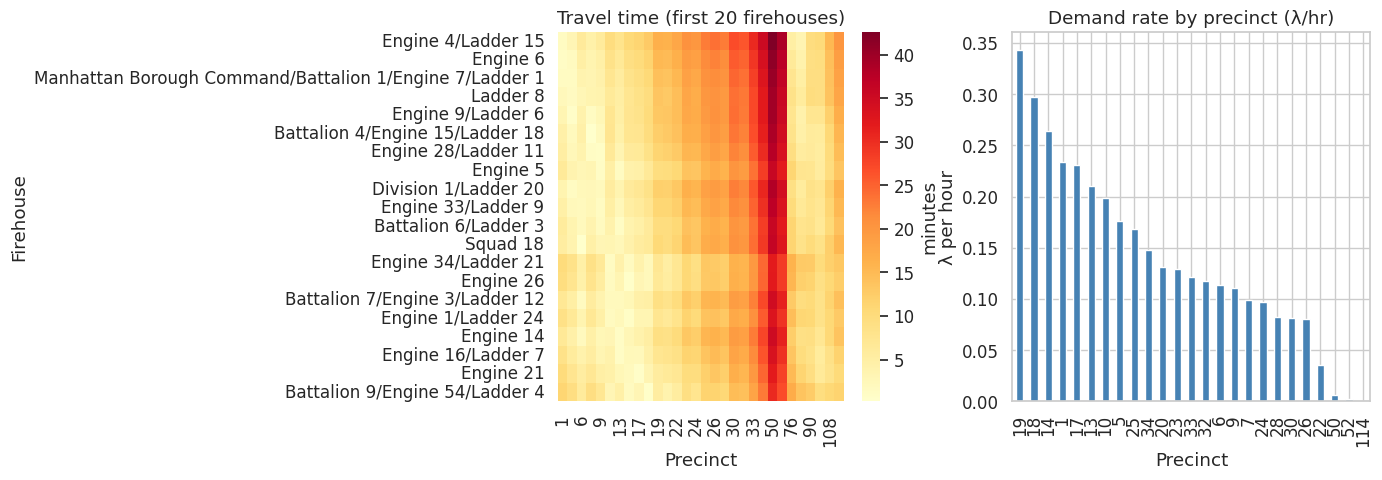

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Travel-time heatmap (subset)
tt = allocator.travel_time
ax = axes[0]
sns.heatmap(tt.iloc[:20, :], cmap="YlOrRd", ax=ax, cbar_kws={"label": "minutes"})
ax.set_title("Travel time (first 20 firehouses)")
ax.set_xlabel("Precinct")
ax.set_ylabel("Firehouse")

# Demand bar chart
dem = allocator.demand.sort_values(ascending=False)
ax = axes[1]
dem.plot.bar(ax=ax, color="steelblue")
ax.set_title("Demand rate by precinct (λ/hr)")
ax.set_ylabel("λ per hour")
ax.set_xlabel("Precinct")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "opt_inputs.png", dpi=150)
plt.show()

## 2 — Solve all models for K = 40

In [4]:
K = 40
capacity = allocator.config.get("firehouse_capacity", 5)
tau = allocator.config.get("coverage_threshold_minutes", 8)

comparison = allocator.compare_models(K=K, capacity=capacity, coverage_threshold=tau)
comparison

,model,K,status,objective,active_firehouses,units_deployed,solve_time_sec,covered_precincts,total_precincts,pct_precincts,covered_demand_pct
0,uniform,40,Baseline,3.0194,40,40,0.000,25,25,100.0,100.0
1,demand_proportional,40,Baseline,2.5199,21,40,0.000,25,25,100.0,100.0
2,demand_weighted,40,Optimal,2.4935,24,40,0.037,25,25,100.0,100.0
3,p_median,40,Optimal,2.4935,40,40,0.037,25,25,100.0,100.0
4,maximal_coverage,40,Optimal,3.4821,10,40,0.006,25,25,100.0,100.0


## 3 — Detailed allocation: Demand-Weighted model

In [5]:
res_dw = allocator.solve("demand_weighted", K=K, capacity=capacity)
print(f"Status        : {res_dw.status}")
print(f"Objective     : {res_dw.objective_value:.4f}")
print(f"Active FHs    : {res_dw.active_firehouses}")
print(f"Solve time    : {res_dw.solve_time_sec:.2f}s")

alloc_dw = res_dw.allocation[res_dw.allocation > 0].sort_values(ascending=False)
print(f"\nTop 10 firehouses:")
print(alloc_dw.head(10))

Status        : Optimal
Objective     : 2.4935
Active FHs    : 24
Solve time    : 0.04s

Top 10 firehouses:
Battalion 4/Engine 15/Ladder 18     5
Battalion 16/Engine 69/Ladder 28    5
Battalion 2/Engine 24/Ladder 5      5
Battalion 13/Engine 93/Ladder 45    5
Engine 34/Ladder 21                 1
Engine 9/Ladder 6                   1
Engine 28/Ladder 11                 1
Squad 18                            1
Engine 21                           1
Engine 14                           1
Name: units_allocated, dtype: int64


## 4 — Detailed allocation: P-Median model

In [6]:
res_pm = allocator.solve("p_median", K=20, capacity=capacity)
print(f"Status        : {res_pm.status}")
print(f"Objective     : {res_pm.objective_value:.4f}")
print(f"Active FHs    : {res_pm.active_firehouses}")
print(f"Solve time    : {res_pm.solve_time_sec:.2f}s")

alloc_pm = res_pm.allocation[res_pm.allocation > 0].sort_values(ascending=False)
print(f"\nSelected firehouses ({len(alloc_pm)}):")
print(alloc_pm)

Status        : Optimal
Objective     : 2.5442
Active FHs    : 20
Solve time    : 0.04s

Selected firehouses (20):
Engine 9/Ladder 6                   1
Battalion 4/Engine 15/Ladder 18     1
Engine 28/Ladder 11                 1
Squad 18                            1
Engine 34/Ladder 21                 1
Engine 26                           1
Engine 14                           1
Engine 21                           1
Battalion 9/Engine 54/Ladder 4      1
Division 3/Ladder 25                1
Engine 44                           1
Engine 53/Ladder 43                 1
Battalion 12/Engine 35/Ladder 14    1
Battalion 11/Engine 76/Ladder 22    1
Engine 37/Ladder 40                 1
Engine 95/Ladder 36                 1
Battalion 16/Engine 69/Ladder 28    1
Engine 80/Ladder 23                 1
Engine 10/Ladder 10                 1
Engine 67                           1
Name: units_allocated, dtype: int64


## 5 — Detailed allocation: Maximal Coverage model

In [7]:
res_mc = allocator.solve("maximal_coverage", K=K, capacity=capacity, coverage_threshold=tau)
print(f"Status             : {res_mc.status}")
print(f"Covered demand obj : {res_mc.objective_value:.4f}")
cov = res_mc.coverage
print(f"Precincts covered  : {cov.sum()} / {len(cov)}")
print(f"Solve time         : {res_mc.solve_time_sec:.2f}s")

alloc_mc = res_mc.allocation[res_mc.allocation > 0].sort_values(ascending=False)
print(f"\nTop 10 firehouses:")
print(alloc_mc.head(10))

Status             : Optimal
Covered demand obj : 3.4821
Precincts covered  : 25 / 25
Solve time         : 0.01s

Top 10 firehouses:
Engine 34/Ladder 21                 5
Battalion 8/Engine 8/Ladder 2       5
Rescue 1                            5
Battalion 10/Engine 22/Ladder 13    5
Battalion 12/Engine 35/Ladder 14    5
Battalion 11/Engine 76/Ladder 22    5
Engine 65                           5
Battalion 13/Engine 93/Ladder 45    3
Division 1/Ladder 20                1
Engine 95/Ladder 36                 1
Name: units_allocated, dtype: int64


## 6 — Sensitivity: vary total units K

In [8]:
unit_counts = allocator.config.get("unit_counts", [20, 30, 40, 48])
rows = []
for k in unit_counts:
    comp = allocator.compare_models(K=k, capacity=capacity, coverage_threshold=tau)
    rows.append(comp)

sensitivity = pd.concat(rows, ignore_index=True)
sensitivity

,model,K,status,objective,active_firehouses,units_deployed,solve_time_sec,covered_precincts,total_precincts,pct_precincts,covered_demand_pct
0,uniform,20,Baseline,18.5461,20,20,0.000,14,25,56.0,73.0
1,demand_proportional,20,Baseline,2.8696,18,20,0.000,25,25,100.0,100.0
2,demand_weighted,20,Optimal,2.5442,20,20,0.040,25,25,100.0,100.0
3,p_median,20,Optimal,2.5442,20,20,0.039,25,25,100.0,100.0
4,maximal_coverage,20,Optimal,3.4821,7,20,0.006,25,25,100.0,100.0
5,uniform,30,Baseline,6.9969,30,30,0.000,21,25,84.0,92.0
6,demand_proportional,30,Baseline,2.5199,21,30,0.000,25,25,100.0,100.0
7,demand_weighted,30,Optimal,2.4935,23,30,0.037,25,25,100.0,100.0
8,p_median,30,Optimal,2.4935,30,30,0.040,25,25,100.0,100.0
9,maximal_coverage,30,Optimal,3.4821,8,30,0.006,25,25,100.0,100.0


## 7 — Visualisations

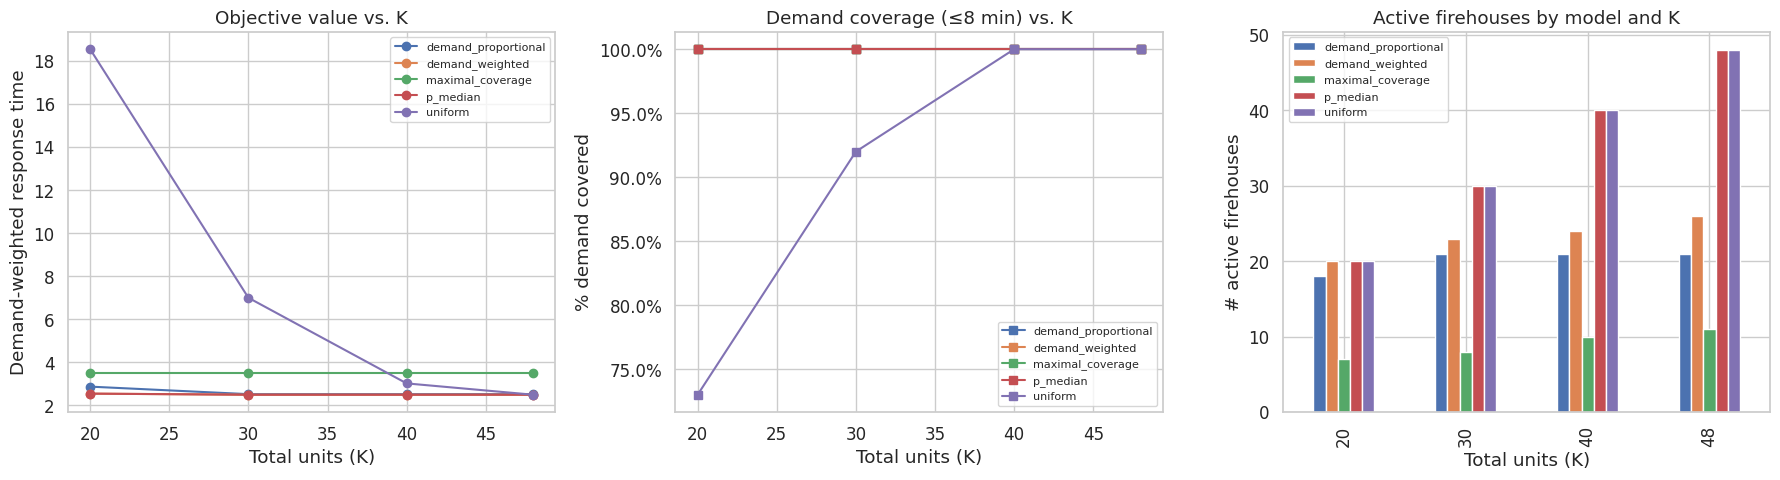

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7a: Objective value by model and K
pivot_obj = sensitivity.pivot(index="K", columns="model", values="objective")
pivot_obj.plot(marker="o", ax=axes[0])
axes[0].set_title("Objective value vs. K")
axes[0].set_ylabel("Demand-weighted response time")
axes[0].set_xlabel("Total units (K)")
axes[0].legend(fontsize=8)

# 7b: Coverage % by model and K
pivot_cov = sensitivity.pivot(index="K", columns="model", values="covered_demand_pct")
pivot_cov.plot(marker="s", ax=axes[1])
axes[1].set_title(f"Demand coverage (≤{tau} min) vs. K")
axes[1].set_ylabel("% demand covered")
axes[1].set_xlabel("Total units (K)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(fontsize=8)

# 7c: Active firehouses
pivot_fh = sensitivity.pivot(index="K", columns="model", values="active_firehouses")
pivot_fh.plot(kind="bar", ax=axes[2])
axes[2].set_title("Active firehouses by model and K")
axes[2].set_ylabel("# active firehouses")
axes[2].set_xlabel("Total units (K)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "opt_sensitivity.png", dpi=150)
plt.show()

## 8 — Allocation comparison (K=40)

In [10]:
# Compare allocations across models for K=40
res_unif = allocator.baseline_uniform(K=K, capacity=capacity)
res_dp   = allocator.baseline_demand_proportional(K=K, capacity=capacity)

all_alloc = pd.DataFrame({
    "Uniform": res_unif.allocation,
    "Demand-Prop": res_dp.allocation,
    "Demand-Wt": res_dw.allocation,
    "MaxCoverage": res_mc.allocation,
})
# Show only firehouses with any allocation
mask = all_alloc.sum(axis=1) > 0
all_alloc_active = all_alloc[mask].sort_values("Demand-Wt", ascending=False)
print(f"Firehouses with ≥1 unit in any model: {mask.sum()}")
all_alloc_active.head(15)

Firehouses with ≥1 unit in any model: 47


,Uniform,Demand-Prop,Demand-Wt,MaxCoverage
Battalion 4/Engine 15/Ladder 18,1,1,5,0
Battalion 16/Engine 69/Ladder 28,0,1,5,0
Battalion 2/Engine 24/Ladder 5,0,0,5,0
Battalion 13/Engine 93/Ladder 45,0,0,5,3
Engine 26,1,3,1,0
Engine 9/Ladder 6,1,2,1,0
Engine 28/Ladder 11,1,1,1,0
Battalion 9/Engine 54/Ladder 4,1,4,1,0
Division 3/Ladder 25,1,2,1,0
Engine 21,1,3,1,0


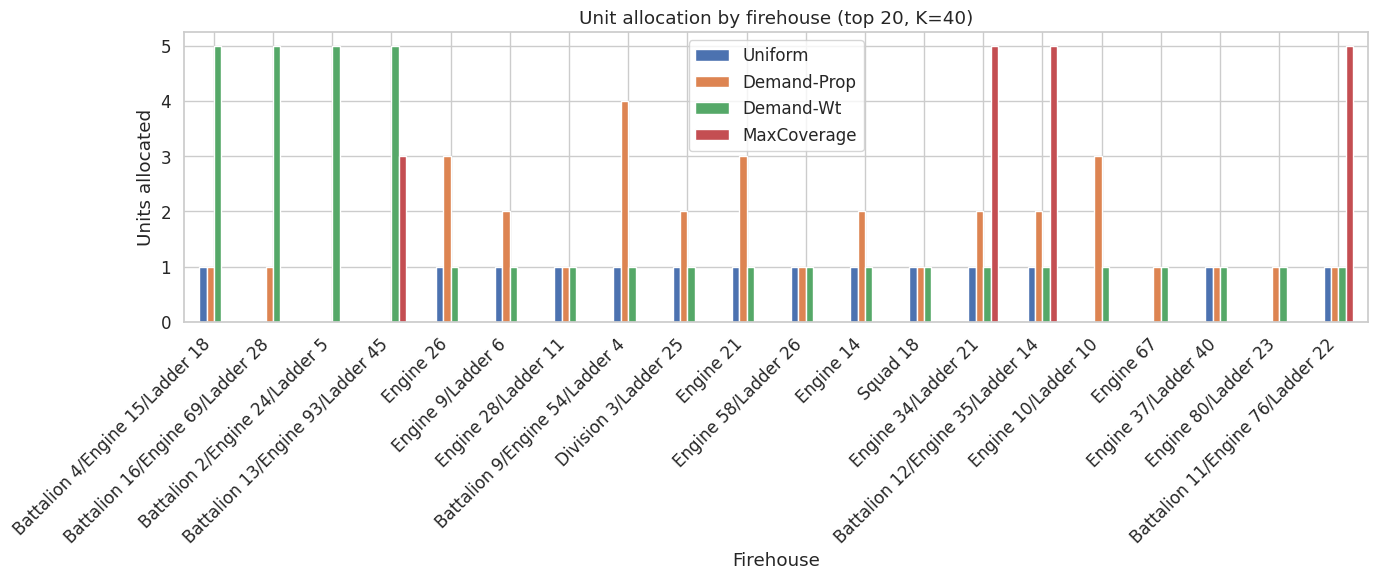

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
all_alloc_active.head(20).plot(kind="bar", ax=ax)
ax.set_title("Unit allocation by firehouse (top 20, K=40)")
ax.set_ylabel("Units allocated")
ax.set_xlabel("Firehouse")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "opt_allocation_comparison.png", dpi=150)
plt.show()

## 9 — Summary & Next Steps

| Finding | Detail |
|---------|--------|
| Best model for min response time | Demand-weighted MIP |
| Typical solve time | < 5 seconds (CBC) |
| Coverage at K=40 | See table above |
| Recommended next phase | P3 – time-varying staging using hourly λ tables |

All results saved to `results/figures/` and `results/tables/`.

In [12]:
# Save comparison table
(PROJECT_ROOT / "results" / "tables").mkdir(parents=True, exist_ok=True)
sensitivity.to_csv(PROJECT_ROOT / "results" / "tables" / "optimization_comparison.csv", index=False)
print("Saved: results/tables/optimization_comparison.csv")
print("Done!")

Saved: results/tables/optimization_comparison.csv
Done!
